In [1]:
import numpy as np
import scipy.signal
import tensorstore as ts
from sklearn.neighbors import KDTree
import matplotlib.pyplot as plt
import asyncio
# from tqdm.asyncio import tqdm_asyncio
from mpl_toolkits.axes_grid1 import ImageGrid

## Load trigger data

In [2]:

def load_stimuli_and_ephys(file_handle, num_channels=10):
  try:
    data = np.fromfile(file_handle, dtype=np.float32)
  except io.UnsupportedOperation:
    data = np.frombuffer(file_handle.read(), dtype=np.float32)
  if data.size % num_channels:
    raise ValueError(f'Data does not fit in num_channels: {num_channels}')
  return data.reshape((-1, num_channels)).T

with open('/groups/saalfeld/saalfeldlab/zapbench-release/volumes/20240930/stimuli_raw/stimuli_and_ephys.10chFlt', 'rb') as f:
  stimuli_and_ephys = load_stimuli_and_ephys(f)

In [3]:
# ttls trace is acquired at 6 kHz.
ttls_freq_khz = 6.0

In [4]:
ttls = stimuli_and_ephys[2]
ttls_high = scipy.signal.find_peaks(ttls, distance=500, height=3.55)[0]
ttls_low = scipy.signal.find_peaks(ttls, distance=50, height=1)[0]

# This logic from the zapbench notebook doesn't work. There are instances
# where you find low_peaks displaced from the high_peak by a small distance.
# this results in the `low_peaks` signal falsely reporting 73 frames per stack.
# See interval tree logic below.

# remove volume imaging start steps and only keep plane imaging steps
# low_peaks = np.array([l for l in ttls_low if l not in ttls_high])
# high_peaks = ttls_high

# if a low peak is within 5 time steps of a high peak we delete it.
tree = KDTree(np.expand_dims(ttls_low, 1))
inds = tree.query_radius(np.expand_dims(ttls_high, 1), r=5)
select = np.ones_like(ttls_low, dtype=bool)
for i in inds:
  for j in i:
    select[j] = False
low_peaks = ttls_low[select]
high_peaks = ttls_high

In [5]:
len(high_peaks)

7872

57 slices


Text(0, 0.5, 'ttls value')

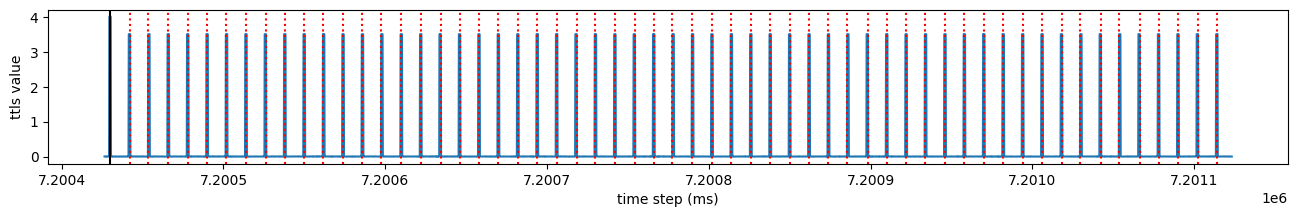

In [6]:
# which time step to visualize. Valid = 0, ..., 7871
# Note that 7871 is a partial trace - only 57 low peaks. Others are complete
# and have the expected 72 steps.
index = 7871
imin = high_peaks[index] - 20
imax = high_peaks[index+1] + 20 if index + 1 < len(high_peaks) else len(ttls)


plt.figure(figsize=(16,2))
plt.plot(np.arange(imin, imax)/ttls_freq_khz, ttls[imin:imax])

jmin, jmax = np.searchsorted(low_peaks, [imin, imax])
print(jmax-jmin, "slices")
for x in low_peaks[jmin:jmax]:
  plt.axvline(x/ttls_freq_khz, color="r", ls="dotted")

for x in high_peaks[index:index+2]:
  plt.axvline(x/ttls_freq_khz, color="k")
plt.xlabel("time step (ms)")
plt.ylabel("ttls value")


In [7]:
# assertions to check our understanding
# for whatever reason we only have data for t=0, ..., 7871
num_time_steps = 7872
zsteps = 72

# 72 low peaks between adjacent high peaks
assert (high_peaks[1:] > high_peaks[:-1]).all()
zstack_index = np.searchsorted(high_peaks, low_peaks) - 1
frames_per_zstack = np.bincount(zstack_index)
# 7871 zstacks have exactly 72 slices (as expected)
# But the last zstack has only 57 slices - maybe we stopped recording it?
frames_per_zstack, np.unique(frames_per_zstack, return_counts=True),


(array([72, 72, 72, ..., 72, 72, 57], shape=(7872,)),
 (array([57, 72]), array([   1, 7871])))

In [8]:
# we have complete info for these
# we will just average and assume the same pattern for what we don't observe
ts_per_slice = low_peaks[:(num_time_steps-1)*zsteps].reshape((-1, zsteps))
print(ts_per_slice.shape)


(7871, 72)


In [9]:
# impute missing data by fitting the observed frames

xvs = np.arange(ts_per_slice.shape[0])
fit = np.polyfit(xvs, ts_per_slice[:, 0], 1)
unk_xvs = np.arange(ts_per_slice.shape[0], 7879)
pred_first = np.expand_dims((fit[0]*unk_xvs + fit[1]), 1)
offset_remaining = np.expand_dims((ts_per_slice - ts_per_slice[:, :1]).mean(axis=0), 0)
pred_ts_per_slice_remaining = (pred_first + offset_remaining).astype(np.int64)

timestamps_ms = np.concatenate([ts_per_slice, pred_ts_per_slice_remaining], axis=0).astype(np.float32)
# set origin to t=0
timestamps_ms -= timestamps_ms[0, 0]
# change units to ms
timestamps_ms /= ttls_freq_khz
# round
timestamps_ms = timestamps_ms.astype(np.int32)
print(timestamps_ms.shape)

(7879, 72)


In [10]:
# Pull data from google storage since the raw data takes a while to download
gs_uri = "gs://zapbench-release/volumes/20240930"

ds = ts.open({
    'open': True,
    'driver': 'zarr3',
    'kvstore': f'{gs_uri}/traces'
}).result()
# Check that we have a time stamp for each neuronal trace
assert ds.shape[0] == timestamps_ms.shape[0]

E0205 17:04:30.812085     192 google_auth_provider.cc:188] Could not find the credentials file in the standard gcloud location [/home/node/.config/gcloud/application_default_credentials.json]. You may specify a credentials file using $GOOGLE_APPLICATION_CREDENTIALS, or to use Google application default credentials, run: gcloud auth application-default login


## examine stimulus data

In [11]:
# Load stimuli
ds = ts.open({
    'open': True,
    'driver': 'zarr2',
    'kvstore': f'{gs_uri}/stimuli_features'
}).result()
stimuli_feats = ds.read().result()

In [12]:
# get condition indices in ttls time steps
trial_id = stimuli_and_ephys[4]

# vel = stimuli_and_ephys[8, ixs]]
bdy = np.where(trial_id[:-1] != trial_id[1:])[0].tolist()
bdy.append(trial_id.shape[0])

In [13]:
from zapbench.constants import CONDITION_NAMES, CONDITION_OFFSETS


In [14]:
v = stimuli_and_ephys[8]
x = stimuli_and_ephys[0]
y = stimuli_and_ephys[1]


In [15]:
import numpy as np
from scipy import signal

def robust_sigma_mad(x):
    med = np.median(x)
    mad = np.median(np.abs(x - med))
    return 1.4826 * mad

def butter_sos(fs, btype, lo=None, hi=None, order=4):
    nyq = 0.5 * fs
    if btype == "bandpass":
        if lo is None or hi is None:
            raise ValueError("bandpass needs lo and hi")
        wn = [lo/nyq, hi/nyq]
    elif btype == "lowpass":
        if hi is None:
            raise ValueError("lowpass needs hi")
        wn = hi/nyq
    elif btype == "highpass":
        if lo is None:
            raise ValueError("highpass needs lo")
        wn = lo/nyq
    else:
        raise ValueError("btype must be bandpass/lowpass/highpass")

    if isinstance(wn, list):
        if not (0 < wn[0] < wn[1] < 1):
            raise ValueError("Bad band edges for this fs")
    else:
        if not (0 < wn < 1):
            raise ValueError("Bad cutoff for this fs")

    return signal.butter(order, wn, btype=btype.replace("pass", ""), output="sos")

def detect_crossings_chunked(
    x, fs,
    bp_lo=100.0, bp_hi=1000.0, bp_order=4,
    thr_k=6.0, polarity="both",
    refractory_ms=2.0,
    chunk_s=10.0, overlap_s=1.0,
    sigma_est_s=60.0
):
    x = np.asarray(x, dtype=np.float32)
    n = x.size

    sos_bp = butter_sos(fs, "bandpass", lo=bp_lo, hi=bp_hi, order=bp_order)

    # robust sigma estimate on first sigma_est_s seconds
    est_len = min(n, int(sigma_est_s * fs))
    y_est = signal.sosfilt(sos_bp, x[:est_len])
    sigma = robust_sigma_mad(y_est)

    if polarity == "neg":
        thr = -thr_k * sigma
    elif polarity == "pos":
        thr = thr_k * sigma
    elif polarity == "both":
        thr = (thr_k * sigma, -thr_k * sigma)
    else:
        raise ValueError("polarity must be neg/pos/both")

    refractory = max(1, int((refractory_ms / 1000.0) * fs))
    chunk_len = int(chunk_s * fs)
    overlap_len = int(overlap_s * fs)
    step = chunk_len - overlap_len
    if step <= 0:
        raise ValueError("chunk_s must be > overlap_s")

    zi = signal.sosfilt_zi(sos_bp).astype(np.float32)

    events = []
    last = -10**18

    start = 0
    while start < n:
        end = min(n, start + chunk_len)
        y, zi = signal.sosfilt(sos_bp, x[start:end], zi=zi)

        core_start = 0 if start == 0 else overlap_len
        core_end = len(y) if end == n else len(y) - overlap_len
        y_core = y[core_start:core_end]
        base = start + core_start

        if polarity == "neg":
            mask = y_core < thr
        elif polarity == "pos":
            mask = y_core > thr
        else:
            pos_thr, neg_thr = thr
            mask = (y_core > pos_thr) | (y_core < neg_thr)

        m = mask.astype(np.int8)
        onsets = np.flatnonzero((m[1:] == 1) & (m[:-1] == 0)) + 1

        for o in onsets:
            idx = base + int(o)
            if idx - last >= refractory:
                events.append(idx)
                last = idx

        start += step

    events = np.asarray(events, dtype=np.int64)
    return events, events / fs, thr, float(sigma)

def detect_bouts_envelope_chunked(
    x, fs,
    bp_lo=100.0, bp_hi=1000.0, bp_order=4,
    env_lp_hz=10.0, env_lp_order=2,
    thr_k=3.0,
    min_bout_s=0.05,
    merge_gap_s=0.05,
    chunk_s=10.0, overlap_s=2.0,
    sigma_est_s=60.0
):
    """
    Bout detection using:
      bandpass -> Hilbert envelope -> lowpass -> threshold

    Returns:
      bouts: list of (start_idx, end_idx) inclusive-exclusive
      bouts_t: list of (start_s, end_s)
      env_thr: threshold on smoothed envelope
      env_sigma: robust sigma estimate of smoothed envelope baseline
    """
    x = np.asarray(x, dtype=np.float32)
    n = x.size

    sos_bp = butter_sos(fs, "bandpass", lo=bp_lo, hi=bp_hi, order=bp_order)
    sos_lp = butter_sos(fs, "lowpass", hi=env_lp_hz, order=env_lp_order)

    # Estimate envelope baseline sigma on first sigma_est_s seconds
    est_len = min(n, int(sigma_est_s * fs))
    y_est = signal.sosfilt(sos_bp, x[:est_len])
    env_est = np.abs(signal.hilbert(y_est.astype(np.float64))).astype(np.float32)
    env_sm_est = signal.sosfilt(sos_lp, env_est)
    env_sigma = robust_sigma_mad(env_sm_est)
    env_med = np.median(env_sm_est)
    env_thr = env_med + thr_k * env_sigma  # envelope is positive; threshold above baseline

    chunk_len = int(chunk_s * fs)
    overlap_len = int(overlap_s * fs)
    step = chunk_len - overlap_len
    if step <= 0:
        raise ValueError("chunk_s must be > overlap_s")

    # streaming states
    zi_bp = signal.sosfilt_zi(sos_bp).astype(np.float32)
    zi_lp = signal.sosfilt_zi(sos_lp).astype(np.float32)

    active = False
    bout_start = None
    bouts = []

    min_len = int(min_bout_s * fs)
    merge_gap = int(merge_gap_s * fs)

    # We'll build a boolean "active" mask in streaming fashion and convert to bouts
    # Commit only core, but keep state across chunks.
    start = 0
    global_idx = 0

    while start < n:
        end = min(n, start + chunk_len)
        y, zi_bp = signal.sosfilt(sos_bp, x[start:end], zi=zi_bp)

        # Hilbert is not truly streaming; do it per chunk with overlap to reduce edge effects.
        # (This is why overlap_s is larger here.)
        env = np.abs(signal.hilbert(y.astype(np.float64))).astype(np.float32)
        env_sm, zi_lp = signal.sosfilt(sos_lp, env, zi=zi_lp)

        core_start = 0 if start == 0 else overlap_len
        core_end = len(env_sm) if end == n else len(env_sm) - overlap_len
        env_core = env_sm[core_start:core_end]
        base = start + core_start

        mask = env_core > env_thr

        # Convert mask to bouts while respecting streaming continuity
        for i, m in enumerate(mask):
            idx = base + i  # global sample index
            if m and not active:
                active = True
                bout_start = idx
            elif (not m) and active:
                active = False
                bout_end = idx  # end is exclusive
                if bout_end - bout_start >= min_len:
                    bouts.append((bout_start, bout_end))
                bout_start = None

        start += step

    # Close trailing bout if it runs to end
    if active and bout_start is not None:
        bout_end = n
        if bout_end - bout_start >= min_len:
            bouts.append((bout_start, bout_end))

    # Merge bouts separated by short gaps
    if bouts:
        merged = [bouts[0]]
        for s, e in bouts[1:]:
            ps, pe = merged[-1]
            if s - pe <= merge_gap:
                merged[-1] = (ps, e)
            else:
                merged.append((s, e))
        bouts = merged

    bouts_t = [(s/fs, e/fs) for s, e in bouts]
    return bouts, bouts_t, float(env_thr), float(env_sigma)

# # ---- Example usage ----
# # x = ...  # your 1D trace
# fs = 6000
# #
# # # 1) Crossings in EMG band (good for quick sanity / event rate)
# events_idx, events_t, thr, sigma = detect_crossings_chunked(
#     x, fs=fs, bp_lo=100, bp_hi=1000, thr_k=6, polarity="both", refractory_ms=2.0
# )
# print("Crossings:", len(events_t), "sigma:", sigma, "thr:", thr)

# # 2) Bout epochs (usually more meaningful for tail)
# bouts, bouts_t, env_thr, env_sigma = detect_bouts_envelope_chunked(
#     x, fs=fs, bp_lo=100, bp_hi=1000, env_lp_hz=10, thr_k=3.0,
#     min_bout_s=0.05, merge_gap_s=0.05
# )
# print("Bouts:", len(bouts), "env_thr:", env_thr, "env_sigma:", env_sigma)


In [16]:
CONDITION_NAMES

('gain',
 'dots',
 'flash',
 'taxis',
 'turning',
 'position',
 'open loop',
 'rotation',
 'dark')

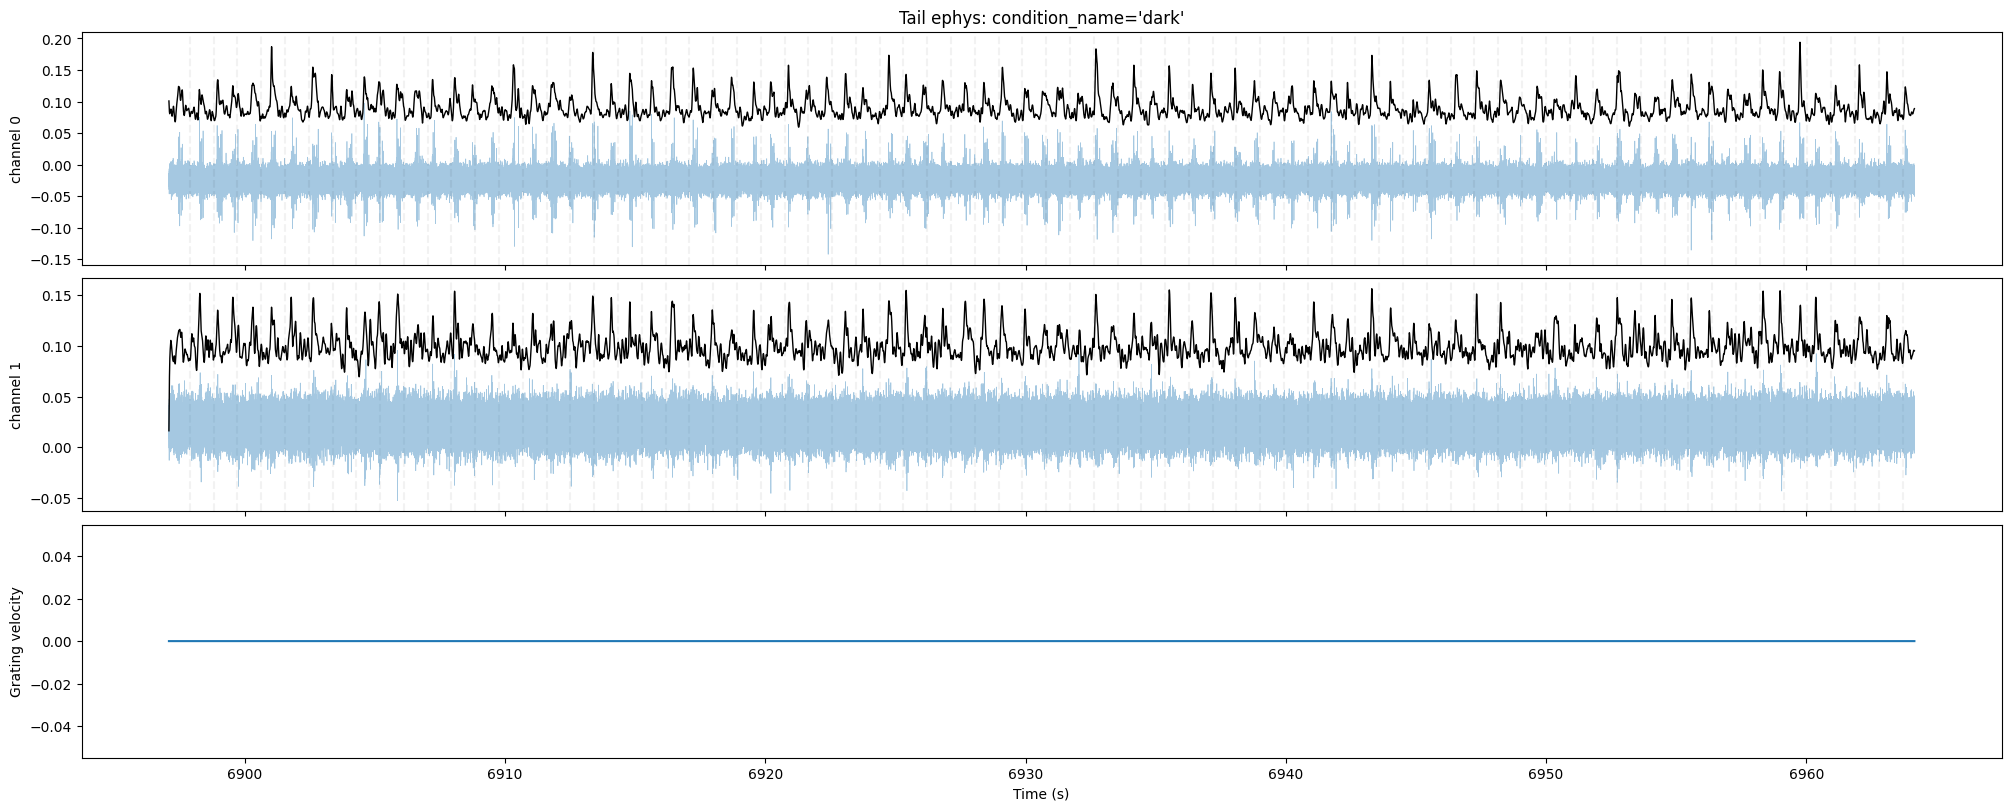

In [ ]:

def plot_bout(
    x, y, fs, bout,
    bp_lo=100, bp_hi=1000,
    env_lp_hz=10,
    pad_s=0.2,        # extra time before/after bout (seconds)
):
    """
    Plot a single bout with raw, bandpassed EMG, and envelope.
    """
    n = len(x)
    s, e = bout

    pad = int(pad_s * fs)
    s0 = max(0, s - pad)
    e0 = min(n, e + pad)

    t = np.arange(s0, e0) / fs
    x_seg = x[s0:e0].copy()
    y_seg = y[s0:e0].copy()

    # --- filters ---
    sos_bp = signal.butter(
        4, [bp_lo/(fs/2), bp_hi/(fs/2)],
        btype="bandpass", output="sos"
    )
    sos_lp = signal.butter(
        2, env_lp_hz/(fs/2),
        btype="lowpass", output="sos"
    )

    # --- process ---
    xemg = signal.sosfiltfilt(sos_bp, x_seg)
    xenv = np.abs(signal.hilbert(xemg))
    xenv_sm = signal.sosfiltfilt(sos_lp, xenv)

    yemg = signal.sosfiltfilt(sos_bp, y_seg)
    yenv = np.abs(signal.hilbert(yemg))
    yenv_sm = signal.sosfiltfilt(sos_lp, yenv)

    # --- plotting ---
    fig, axs = plt.subplots(
        3, 1, figsize=(20, 8),
        sharex=True, constrained_layout=True
    )

    # Raw
    axs[0].plot(t, x_seg, lw=0.5, alpha=0.4)
    axs[0].plot(t, xenv_sm*10, lw=1.0, label="channel 0", color="k")

    label = "imaging start"
    for z in ttls_high:
        if s0 < z < e0:
            axs[0].axvline(z/fs, color="k", ls="dashed", label=label, alpha=0.05)
            axs[1].axvline(z/fs, color="k", ls="dashed", label=label, alpha=0.05)
            label=None

    # axs[0].axvspan(s/fs, e/fs, alpha=0.2)
    axs[0].set_ylabel("channel 0")

    # Bandpassed EMG
    axs[1].plot(t, y_seg, lw=0.5, alpha=0.4)
    axs[1].plot(t, yenv_sm*10, lw=1.0, label="channel 1", color="k")

    # axs[1].axvspan(s/fs, e/fs, alpha=0.2)
    axs[1].set_ylabel("channel 1")



    axs[0].set_title(f"Tail ephys: {condition_name=}")

    axs[2].plot(t, v[s0:e0])
    axs[2].set_ylabel("Grating velocity")
    axs[2].set_xlabel("Time (s)")

    # plt.xlim(s0/fs+1, e0/fs-1)
    plt.show()

condition_name = "dark"
ci = CONDITION_NAMES.index(condition_name)
lo = bdy[ci]
hi = bdy[ci+1]
mp = (lo+hi) // 2
window = 200_000
fs=6000
plot_bout(x, y, fs, bp_lo=50, bp_hi=800, bout=(mp-window, mp+window))

In [ ]:

def design_bp_sos(fs, lo=80.0, hi=1000.0, order=4):
    nyq = fs / 2
    return signal.butter(order, [lo/nyq, hi/nyq], btype="bandpass", output="sos")

def apply_notches(x, fs, freqs, q=30.0):
    """Apply a sequence of IIR notch filters (forward-backward) to reduce tonal interference."""
    y = x.astype(np.float64, copy=False)
    for f0 in freqs:
        if f0 <= 0 or f0 >= fs/2:
            continue
        b, a = signal.iirnotch(w0=f0/(fs/2), Q=q)
        y = signal.filtfilt(b, a, y)
    return y.astype(np.float32)

def binned_emg_envelope(
    x, fs=6000.0, bin_ms=20.0,
    bp_lo=80.0, bp_hi=1000.0,
    notch_freqs=None, notch_q=30.0,
    envelope="abs",          # "abs" or "hilbert"
    agg="mean",              # "mean" or "median"
):
    """
    Returns:
      t_bin: time (s) at bin centers
      emg_bin: binned envelope (positive, rate-like)
    """
    x = np.asarray(x, dtype=np.float32)

    # 1) Optional notch cleanup (helpful given your PSD)
    if notch_freqs:
        x_f = apply_notches(x, fs, notch_freqs, q=notch_q)
    else:
        x_f = x

    # 2) Bandpass to EMG-ish band
    sos = design_bp_sos(fs, lo=bp_lo, hi=bp_hi, order=4)
    emg = signal.sosfiltfilt(sos, x_f.astype(np.float64)).astype(np.float32)

    # 3) Envelope / rectification
    if envelope == "abs":
        env = np.abs(emg)
    elif envelope == "hilbert":
        env = np.abs(signal.hilbert(emg.astype(np.float64))).astype(np.float32)
    else:
        raise ValueError("envelope must be 'abs' or 'hilbert'")

    # 4) Bin to 20 ms
    bin_len = int(round((bin_ms / 1000.0) * fs))
    n = (len(env) // bin_len) * bin_len
    env = env[:n]
    env_2d = env.reshape(-1, bin_len)

    if agg == "mean":
        emg_bin = env_2d.mean(axis=1)
    elif agg == "median":
        emg_bin = np.median(env_2d, axis=1)
    else:
        raise ValueError("agg must be 'mean' or 'median'")

    t_bin = (np.arange(len(emg_bin)) + 0.5) * (bin_len / fs)
    return t_bin, emg_bin

# # Example usage:
# # notch these based on your PSD (adjust to match exact line freqs)
# notch_freqs = [250, 500, 750, 1000, 1250, 1500]
# t20, emg20 = binned_emg_envelope(x, fs=6000, bin_ms=20, bp_lo=80, bp_hi=1000,
#                                 notch_freqs=notch_freqs, envelope="abs", agg="mean")


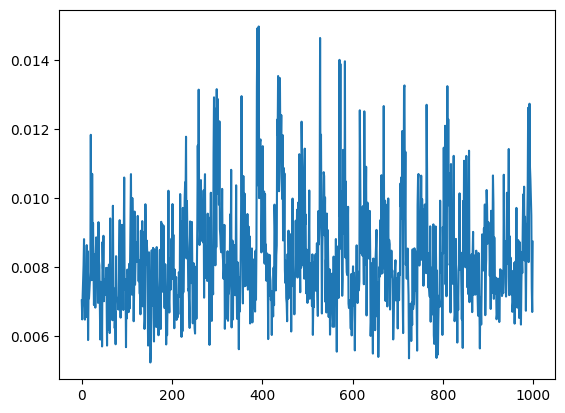

In [302]:
plt.plot(emg20[:1000])

In [317]:
x_seg = x[lo:high].copy()
x_seg -= x_seg.mean()
psd = np.abs(np.fft.rfft(x_seg, norm="ortho"))**2

In [318]:
freq = np.fft.rfftfreq(x_seg.shape[0])

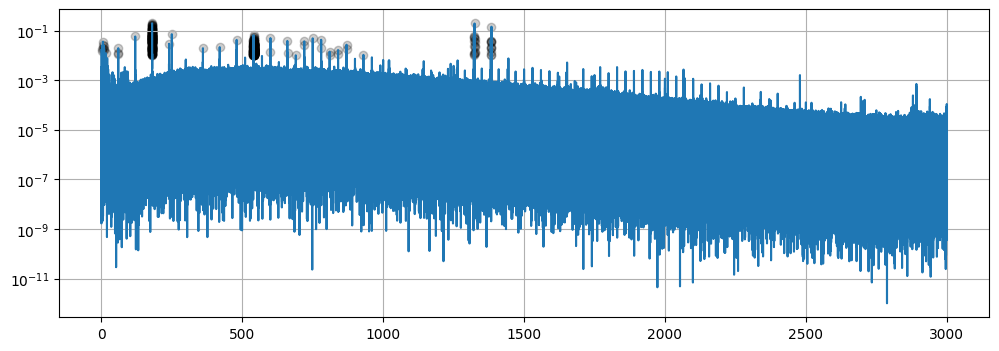

In [331]:
plt.figure(figsize=(12, 4))
plt.plot(freq*6000, psd, )
plt.grid(True)



for f in signal.find_peaks(psd, height=0.01, threshold=0.002)[0]:
    plt.scatter(freq[f]*6000, psd[f], color="k", alpha=0.2, marker="o")

plt.yscale("log")


In [19]:
stimp3 = stimuli_and_ephys[6]

In [21]:
vals, counts = np.unique(stimp3, return_counts=True)

In [28]:
np.where(stimp3 > 40)[0][0]

np.int64(6600140)

In [40]:
tid = int(trial_id[6600140])-1

In [43]:
for tid in range(9):
    print(tid, np.unique(stimp3[bdy[tid]:bdy[tid+1]]))

0 [0. 1. 2.]
1 [ 0.  2. 90.]
2 [0. 1.]
3 [0. 1.]
4 [0. 1.]
5 [-1.  0.  1.]
6 [-1.  1.]
7 [0.000000e+00 3.125000e-02 9.375000e-02 ... 8.990625e+01 8.996875e+01
 9.000000e+01]
8 [-10.     0.25]


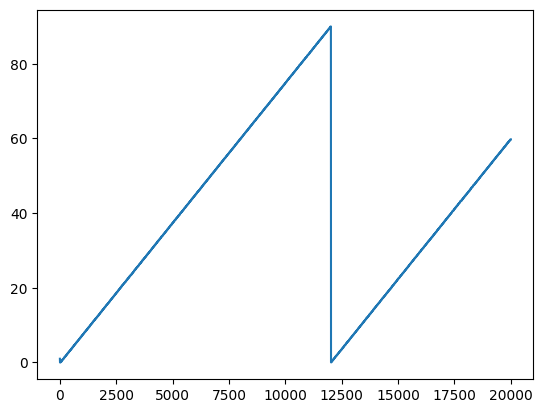

In [50]:
tid = 7

plt.plot(stimp3[bdy[tid]:bdy[tid]+20000])

In [119]:
i = 0
v = stimuli_and_ephys[8, bdy[i]:bdy[i+1]]
x = stimuli_and_ephys[0, bdy[i]:bdy[i+1]]
y = stimuli_and_ephys[1, bdy[i]:bdy[i+1]]

xs = np.convolve(x, np.ones(1000)/1000, mode="full")
ys = np.convolve(y, np.ones(1000)/1000, mode="full")


In [51]:
np.unique(trial_id, return_counts=True)

(array([0., 1., 2., 3., 4., 5., 6., 7., 8.], dtype=float32),
 array([3246060, 3600080, 9720160, 3600060, 3600060, 7200120, 3240040,
        5400100, 3600060]))

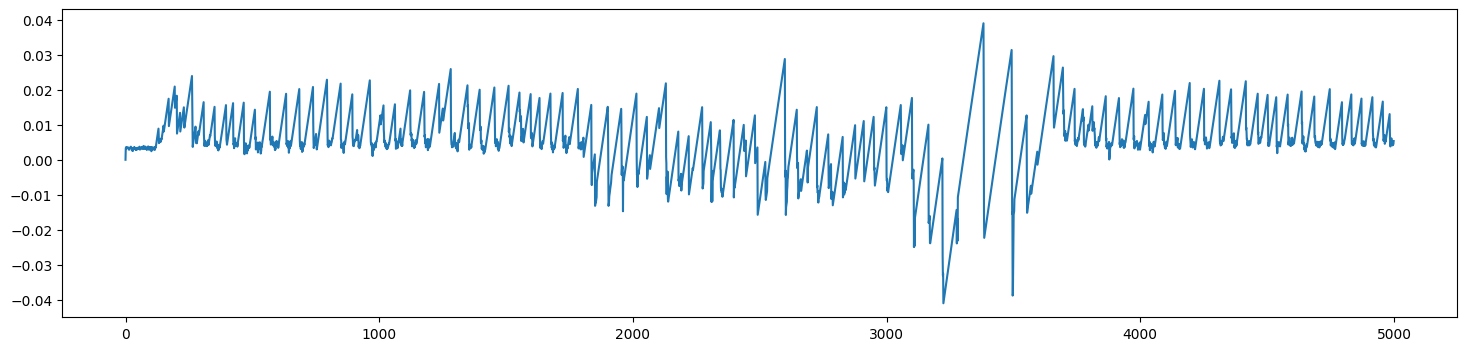

In [163]:
# j = np.random.randint(x.shape[0])

# plt.scatter(x[i-100:i+100], y[i-100:i+100])
plt.figure(figsize=(18, 4))
# plt.plot(xs[:500_000:10])
# plt.plot(ys[:500_000:100])
plt.plot(v[:500_000:100])

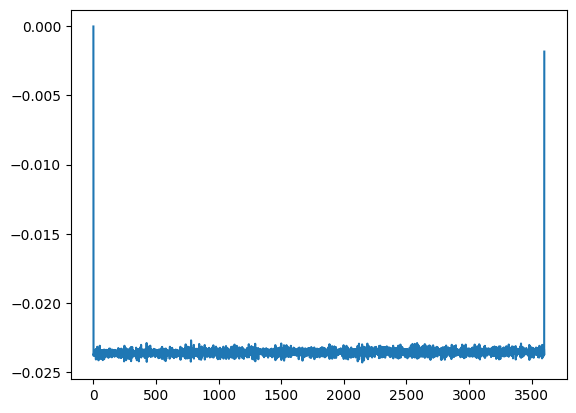

In [118]:
plt.plot(res[::1000])


0.09


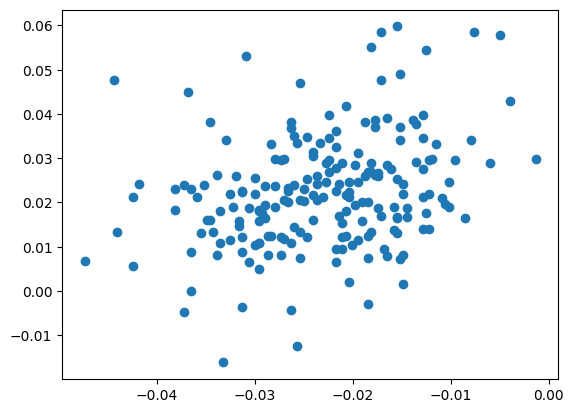

In [83]:
plt.scatter(x[i-100:i+100], y[i-100:i+100])
a, b = np.polyfit(x[i-100:i+100], y[i-100:i+100], 1)
delta = y[i-100:i+100] - (a*x[i-100:i+100] + b)
print(f"{1 - np.var(delta) / np.var(y[i-100:i+100]):.2f}")

In [48]:
np.diff(np.where(np.diff(vel) != 0)[0])

array([180000,     20,     20, ...,     20,     20,     20],
      shape=(13819,))

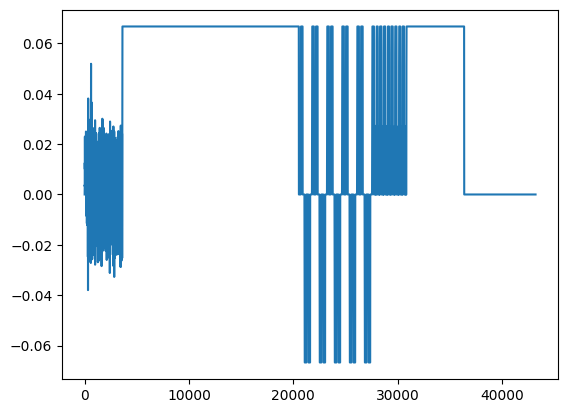

In [40]:
plt.plot(stimuli_and_ephys[8, ::1000])

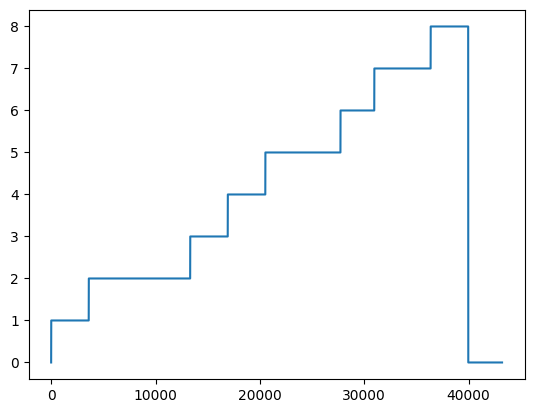

In [32]:
plt.plot(stimuli_and_ephys[4, ::1000])

In [26]:
stimuli_and_ephys.shape[1] / 6 / 60_000

120.01872222222222

## continues

In [20]:
# Load segmentation
ds = ts.open({
    'open': True,
    'driver': 'zarr3',
    'kvstore': f'{gs_uri}/segmentation'
}).result()
segmentation = ds.read().result()

In [ ]:
# process segmentation to build a map between voxels and cell id's

xi, yi, zi = np.where(segmentation > 0)
# get to zero based indexing
cell_id_flat = segmentation[xi, yi, zi].astype(np.uint64)
cell_id_flat -= 1

cell_id_uniq, px_per_cell = np.unique(cell_id_flat, return_counts=True)
num_cells = cell_id_uniq.shape[0]
# cell_id_uniq = 0, 1, 2, ..., N-1
zs_order = np.lexsort((zi, cell_id_flat))
xi = xi[zs_order]
yi = yi[zs_order]
zi = zi[zs_order]
cell_id_flat = cell_id_flat[zs_order]

# Let's make a uint64 key of cellid, z.
# we should assert that cell id's are themselves sorted first.
sort_key = (cell_id_flat << 32).astype(np.uint64) + zi.astype(np.uint64)
assert (sort_key[1:] >= sort_key[:-1]).all()
_, first_index = np.unique(sort_key, return_index=True)

cell_ids = cell_id_flat[first_index].astype(np.int32)
z_per_cell = zi[first_index].astype(np.int32)

px_per_cell_per_z = np.zeros_like(first_index, dtype=np.int32)
px_per_cell_per_z[:-1] = np.diff(first_index)
px_per_cell_per_z[-1] = sort_key.shape[0] - first_index[-1]
assert cell_ids.shape == z_per_cell.shape == px_per_cell_per_z.shape

num_cellz = cell_ids.shape[0]
# each row = cell id C, z slice Z, containing P pixels
print(
  cell_ids[:10].tolist(),
  z_per_cell[:10].tolist(),
  px_per_cell_per_z[:10].tolist()
)
# cell_ids = [0, 0, 0, 1, 1, 1, 2, 2, 2, 2],
# ^ which cell does each piece belong to?

# z_per_cell = [13, 14, 15, 16, 17, 18, 5, 6, 7, 8],
# ^ which z slice is it?

# px_per_cell_per_z = [26, 62, 33, 9, 83, 27, 7, 100, 110, 88])
# ^ how many XY pixels in each piece?

## Plot Ca activity per cell split by z

In [16]:
# this is the df/f data
raw = ts.open({
    'open': True,
    'driver': 'zarr3',
    'kvstore': 'gs://zapbench-release/volumes/20240930/df_over_f_xyz_chunked/s0'
}).result()


In [ ]:
ds = ts.open({
    'open': True,
    'driver': 'zarr3',
    'kvstore': 'gs://zapbench-release/volumes/20240930/traces'
}).result()
traces = ds.read().result()

cell_id=64913


Text(0.5, 1.0, 'cell_id=64913')

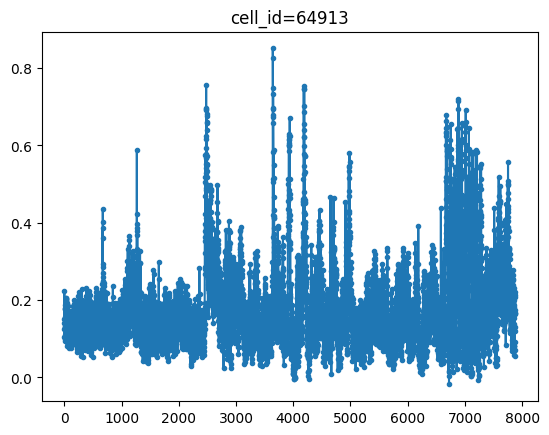

In [18]:
# Pick a cell to plot
cell_id = 64913
# cell_id = np.random.randint(0, 71721)

print(f"{cell_id=}")
i, j, k = np.where(segmentation == cell_id+1)
activity = np.array(traces[:, cell_id])
plt.plot(activity, marker=".")
plt.title(f"{cell_id=}")

In [20]:
tpeak = np.argmax(activity)
print(tpeak)
time_window = 20
tlow = max(tpeak-time_window, 0)
thigh = min(tpeak+time_window, raw.shape[-1]-1)

imin, imax = max(0, i.min()-1), i.max()+1
jmin, jmax = max(0, j.min()-1), j.max()+1
kmin, kmax = k.min(), k.max()+1
print(kmax-kmin, "zslices")
vol = np.array(raw[imin:imax, jmin:jmax, kmin:kmax, tlow:thigh])
mask = (segmentation[imin:imax, jmin:jmax, kmin:kmax] == cell_id+1).astype(np.uint8)

3643
2 zslices


Text(0.5, 0.98, 'cell_id=64913')

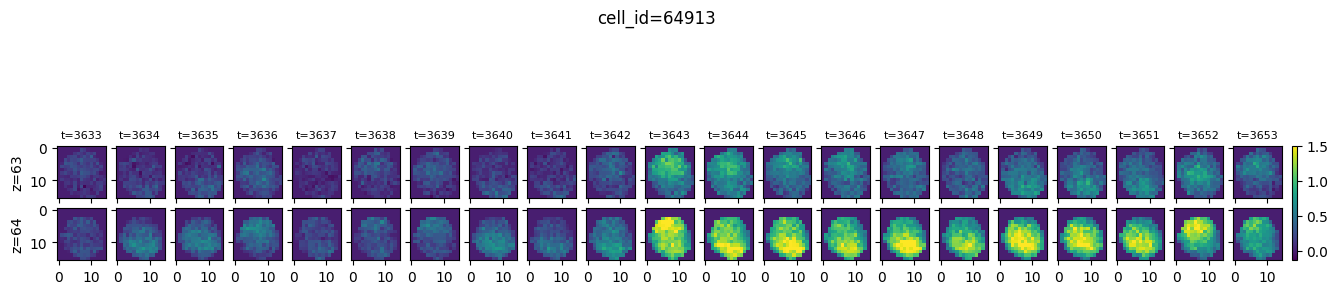

In [23]:
fig=plt.figure(figsize=(16, 4))
w = 10
grid = ImageGrid(fig, 111,  # similar to subplot(111)
                 nrows_ncols=(vol.shape[2], 2*w+1),
                 axes_pad=0.1,
                 cbar_mode="single"
                 )
ax = grid.axes_row
vmin = vol.min()
vmax = vol.max()
for z in range(vol.shape[2]):
  for wi in range(2*w+1):
    im = ax[z][wi].imshow(vol[:, :, z, tpeak-tlow-w+wi]
                          *mask[:, :, z],
                           vmin=vmin, vmax=vmax)
    ax[0][wi].set_title(f"t={tpeak-w+wi}", fontsize=8)
  ax[z][0].set_ylabel(f"z={kmin+z}")
grid.cbar_axes[0].colorbar(im)
plt.suptitle(f"{cell_id=}")

Text(0.5, 0.98, 'cell_id=64913')

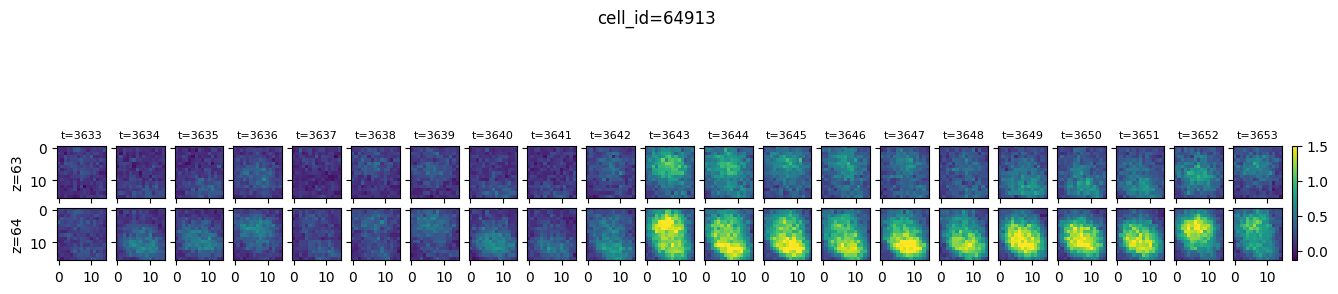

In [25]:
fig=plt.figure(figsize=(16, 4))
w = 10
grid = ImageGrid(fig, 111,  # similar to subplot(111)
                 nrows_ncols=(vol.shape[2], 2*w+1),
                 axes_pad=0.1,
                 cbar_mode="single"
                 )
ax = grid.axes_row
vmin = vol.min()
vmax = vol.max()
for z in range(vol.shape[2]):
  for wi in range(2*w+1):
    im = ax[z][wi].imshow(vol[:, :, z, tpeak-tlow-w+wi],
                           vmin=vmin, vmax=vmax)
    ax[0][wi].set_title(f"t={tpeak-w+wi}", fontsize=8)
  ax[z][0].set_ylabel(f"z={kmin+z}")
grid.cbar_axes[0].colorbar(im)
plt.suptitle(f"{cell_id=}")

Text(0.5, 0, 'time steps around peak')

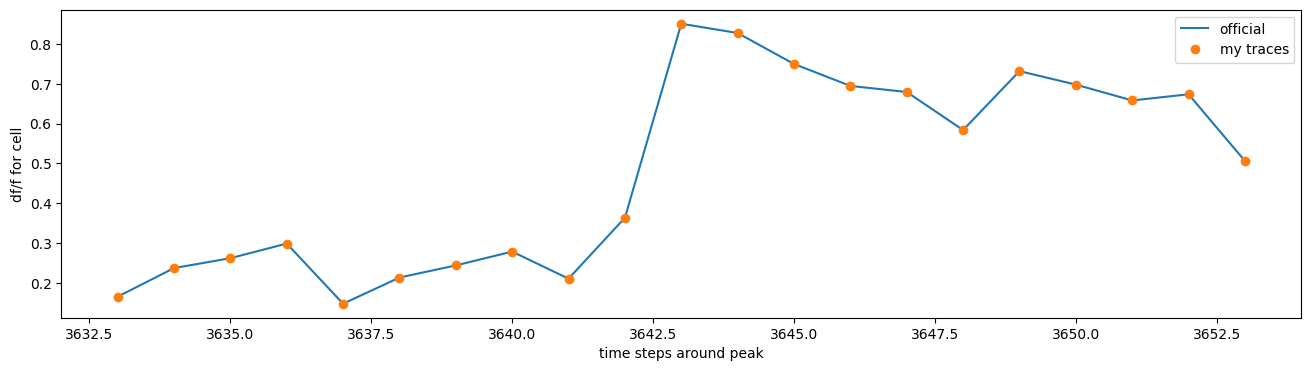

In [28]:
avg = np.array([[vol[:, :, z, tpeak-tlow-w+wi][mask[:, :, z].astype(bool)].mean() for wi in range(2*w+1)] for z in range(vol.shape[2])])
vol_avg = np.array([[vol[:, :, z, tpeak-tlow-w+wi][mask[:, :, z].astype(bool)].sum() for wi in range(2*w+1)] for z in range(vol.shape[2])]).sum(0) / mask.sum()
plt.figure(figsize=(16,4))
plt.plot([tpeak-w+wi for wi in range(2*w+1)], activity[tpeak-w:tpeak+w+1], label="official")
plt.plot([tpeak-w+wi for wi in range(2*w+1)], vol_avg, ls="", marker="o", label="my traces")
plt.legend()
plt.ylabel("df/f for cell")
plt.xlabel("time steps around peak")

## Reprocess data - takes many many hours

Do not rerun since it will attempt to rewrite the data (and fail) </br>
Data available at `/groups/saalfeld/saalfeldlab/zapbench-processed/20251007`

In [ ]:
output_path = "/groups/saalfeld/saalfeldlab/zapbench-processed/20251007"
output_uri = f"file://{output_path}"

In [ ]:
with open(f"{output_path}/per_cell_z_data.npz", "wb") as out:
  np.savez_compressed(
      out,
      cell_id=cell_ids,
      z_cell=z_per_cell,
      num_pxs=px_per_cell_per_z,
      allow_pickle=False,
  )

with open(f"{output_path}/timestamps_ms.npz", "wb") as out:
  np.savez_compressed(
      out,
      timestamps_ms=timestamps_ms,
      allow_pickle=False,
  )

In [ ]:
num_parallel = 4

In [ ]:

async def process_time_point(i, vol):
    """Process a single time slice."""

    vals = vol[xi, yi, zi]
    ixs = np.repeat(np.arange(cell_ids.shape[0]), px_per_cell_per_z)
    slice_avg = np.bincount(ixs, weights=vals).astype(np.float32)
    slice_avg /= px_per_cell_per_z
    return i, slice_avg

async def process_all(output_uri):

    # dF/F data per voxel (chunked spatially for more efficient processing)
    src = await ts.open({
        'open': True,
        'driver': 'zarr3',
        'kvstore': f"{gs_uri}/df_over_f_xyz_chunked/s0",
        "context": {"cache_pool": {"total_bytes_limit": 1024*1024*128}}
    })
    shape = src.domain.shape

    dst_activity = await ts.open({
        "driver": "zarr3",
        "kvstore": f"{output_uri}/cell_z_activity.zarr",
        "dtype": "float32",
        "create": True,
        "delete_existing": False,
    },
    shape=(shape[3], num_cellz),
    )

    dst_timestamps = await ts.open({
        "driver": "zarr3",
        "kvstore": f"{output_uri}/cell_z_time_ms.zarr",
        "dtype": "int32",
        "create": True,
        "delete_existing": False,
    },
    shape=(shape[3], num_cellz),
    )

    semaphore = asyncio.Semaphore(num_parallel)

    async def load_process_write(i):
        async with semaphore:
            chunk = await src[:, :, :, i].read()
            _, processed = await process_time_point(i, chunk)
            await asyncio.gather(
                dst_activity[i, :].write(processed),
                dst_timestamps[i, :].write(timestamps_ms[i, z_per_cell])
            )
            return i

    # Launch all chunk tasks concurrently
    tasks = [asyncio.create_task(load_process_write(i)) for i in range(shape[3])]
    await tqdm_asyncio.gather(*tasks, desc="Processing + Writing chunks", total=len(tasks))

    print("✅ All chunks processed and written to:", output_uri)


await process_all(output_uri)
